In [1]:
!pip install cartopy
!pip install itur


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 35.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.4/163.4 MB 8.6 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.optimize import brentq
import matplotlib.pyplot as plt
import matplotlib
import cartopy
import itur
from itur.models import itu530

In [4]:

def db2lin(db):
    return 10**(db/10)

def calc_capacity_gbps(prx_dBm, band_hz):
  # NOTE: assuming a noise spectral density of -174 dBm/Hz, as per 3GPP reports
  noise_dBm = -174 + 10*np.log10(band_hz)
  return band_hz*np.log2(1 + db2lin(prx_dBm - noise_dBm))/1e9

def calc_pathloss(d_km, fc_ghz):
    # Free-space
    return 92.44 + 20*np.log10(fc_ghz) + 20*np.log10(d_km)

def calc_weather_attenuation(p, d_km, fc_ghz, rain_rate001=42):
    # Note: p in 0-100%; p = 0.01 means 0.01%
    #
    # Re: Rain rate exceeded for 0.01% (rain_rate001):
    # Based on ITU-R P.837-7,
    #   - South US: rain_rate001 is around 40 mm/h
    #   - North US: rain_rate001 is around 25 mm/h

    # Assuming vertical polarization at 28 GHz (see ITU-R P.838-3)
    # NOTE: We must change k, alpha if we change fc_ghz, as per Table 5 in ITU-R P.838-3.
    rain_stats_lookup_table = {
        6: {"k": 0.0004878, "alpha": 1.5728},
        11: {"k": 0.01731, "alpha": 1.1617},
        18: {"k": 0.07708, "alpha": 1.0025},
        23: {"k": 0.1284, "alpha": 0.9630},
        28: {"k": 0.1964, "alpha": 0.9277},
        39: {"k": 0.4058, "alpha": 0.8486},
        80: {"k": 1.1668, "alpha": 0.7021},
    }
    k = rain_stats_lookup_table[fc_ghz]["k"]
    alpha = rain_stats_lookup_table[fc_ghz]["alpha"]
    gamma = k * (rain_rate001**alpha)

    # equation 32 needs to have a d value no larger than 30km for stability
    # old version
    #r_den = 0.477 * (d_km**0.633) * (rain_rate001**(0.073*alpha)) * (fc_ghz**0.123) - 10.579*(1 - np.exp(-0.024*d_km))
    # fixed version
    d_km_temp = np.minimum(d_km, 30)
    r_den = 0.477 * (d_km_temp**0.633) * (rain_rate001**(0.073*alpha)) * (fc_ghz**0.123) - 10.579*(1 - np.exp(-0.024*d_km_temp))
    r = 1/r_den
    a001 = gamma * d_km * r

    c0 = 0.12
    if fc_ghz >= 10:
        #c0 += 0.4*np.log10((fc_ghz/10)**0.8)
        c0 += 0.4*((np.log10(fc_ghz/10))**0.8)

    c1 = (0.07**c0) * (0.12**(1-c0))
    c2 = 0.855*c0 + 0.546*(1-c0)
    c3 = 0.139*c0 + 0.043*(1-c0)

    ap = a001 * c1 * p**(-(c2+c3*np.log10(p)))
    return ap # in dB

def inverse_calc_weather_attenuation(target_A_dB, d_km, fc_ghz, rain_rate001=42):

    def f(p):
        return calc_weather_attenuation(p, d_km, fc_ghz, rain_rate001=rain_rate001) - target_A_dB
    p_min=1e-5*100
    p_max=1e-2*100

    if target_A_dB < calc_weather_attenuation(p_max, d_km, fc_ghz, rain_rate001=rain_rate001):
      return 1e2 # out of range, target very likely to happen, though
    if target_A_dB > calc_weather_attenuation(p_min, d_km, fc_ghz, rain_rate001=rain_rate001):
      return 1e-6 # out of range, target very unlikely to happen, though
    return brentq(f, p_min, p_max)

def pack2dict(dictionary, values):
    assert len(dictionary.keys()) == len(values), "Error! Keys and values must have same length."
    for k, v in zip(dictionary.keys(), values):
        dictionary[k].append(v)
    return dictionary

#start

In [5]:
freq_colors = {
    "6 GHz": sns.color_palette()[0],
    "11 GHz": sns.color_palette()[1],
    "80 GHz": sns.color_palette()[2],
    "18 GHz": sns.color_palette()[3],
    "23 GHz": sns.color_palette()[4],
    "39 GHz": sns.color_palette()[8],
    "6 GHz + 39 GHz": sns.color_palette()[8],
    "6 GHz + 80 GHz": sns.color_palette()[2],
    "11 GHz + 39 GHz": sns.color_palette()[8],
    "11 GHz + 80 GHz": sns.color_palette()[2],
    "6 & 39 GHz": sns.color_palette()[8],
    "6 & 80 GHz": sns.color_palette()[2],
    "11 & 39 GHz": sns.color_palette()[8],
    "11 & 80 GHz": sns.color_palette()[2],
    "18 GHz + 80 GHz": sns.color_palette()[6],
    "18 GHz + 39 GHz": sns.color_palette()[7],
    "23 GHz + 80 GHz": sns.color_palette()[7],
}

In [6]:


# --- compute results over distance, frequency, and p_out ---
distances = [3,5,10] #np.linspace(0.1, 50, 50)

# use more p_out values if you want smooth curves
p_out_values = np.logspace(-2, -5, 50)   # from 1e-2 to 1e-5

results = {"d_km": [], 'Carrier Freq. ($f_c$)': [], "p_out": [], "nines": [], "weatherloss": [], "rain_rate001": []}

for d_km in distances:
    for fc_ghz in [80, 18, 6]:
        for p_out in p_out_values:
            for rain_rate001 in [78.15, 41.27, 26.57]: #[80, 40, 25]:
                wl = calc_weather_attenuation(p=p_out*100, d_km=d_km,
                                              fc_ghz=fc_ghz, rain_rate001=rain_rate001)
                nines = -np.log10(p_out)          # 0.01 -> 2, 1e-5 -> 5, etc.
                results["d_km"].append(d_km)
                results['Carrier Freq. ($f_c$)'].append(f"{fc_ghz} GHz")
                results["p_out"].append(p_out)
                results["nines"].append(nines)
                results["weatherloss"].append(wl)
                results["rain_rate001"].append(f"{rain_rate001} mm/h")

df_res = pd.DataFrame(results)
df_res

,d_km,Carrier Freq. ($f_c$),p_out,nines,weatherloss,rain_rate001
0,3,80 GHz,0.010000,2.000000,5.237988,78.15 mm/h
1,3,80 GHz,0.010000,2.000000,3.522422,41.27 mm/h
2,3,80 GHz,0.010000,2.000000,2.680688,26.57 mm/h
3,3,80 GHz,0.008685,2.061224,5.774321,78.15 mm/h
4,3,80 GHz,0.008685,2.061224,3.883094,41.27 mm/h
...,...,...,...,...,...,...
1345,10,6 GHz,0.000012,4.938776,2.011771,41.27 mm/h
1346,10,6 GHz,0.000012,4.938776,1.139078,26.57 mm/h
1347,10,6 GHz,0.000010,5.000000,4.828756,78.15 mm/h
1348,10,6 GHz,0.000010,5.000000,2.086671,41.27 mm/h


In [7]:
def get_weather_label(rain_rate):
    if rain_rate == "26.57 mm/h":
        return "Dry"
    elif rain_rate == "41.27 mm/h":
        return "Temperate"
    elif rain_rate == "78.15 mm/h":
        return "Tropical"
    else:
        return "Unknown"

df_res['Climate'] = df_res['rain_rate001'].apply(get_weather_label)
df_res["Carrier Freq."] = df_res["Carrier Freq. ($f_c$)"].copy()

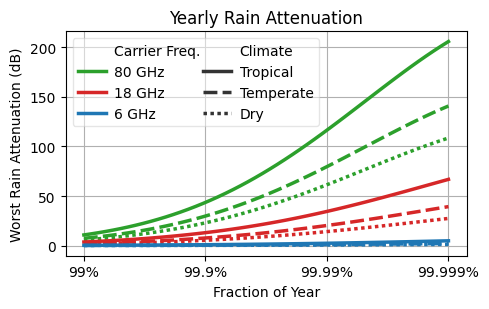

In [8]:
d_fixed = 10
df_plot = df_res[np.isclose(df_res["d_km"], d_fixed)]

fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(5, 3.2))

#plt.figure()
#plt.title(f"Yearly Rain Attenuation Exceedence (d = {d_fixed} km)")

plt.title(r"Yearly Rain Attenuation") # $F^{-1}_{A_w}(\beta)$



ax = sns.lineplot(
    data=df_plot,
    x="nines",
    y="weatherloss",
    hue="Carrier Freq.", # ($f_c$)',
    style="Climate",
    lw=2.5,
    palette=freq_colors
)

plt.ylabel("Worst Rain Attenuation (dB)")
plt.xlabel(r'Fraction of Year') # ($\beta$)
#plt.legend(frameon=False)
#plt.legend(frameon=True,framealpha=0.5, fancybox=True)
leg = plt.legend(frameon=True, framealpha=0.5, fancybox=True, ncol=2, columnspacing=0.2, handletextpad=0.6)
leg._legend_box.align = "left"

# Tick positions = number of nines; labels = percentages
plt.xticks(
    [2, 3, 4, 5],
    labels=["99%", "99.9%", "99.99%", "99.999%"]
)

#plt.legend(title="fc_ghz")
plt.grid(True)
plt.tight_layout()
plt.savefig(f"cap-vs-attenuation_for_rainrate-fc-aspect.pdf", bbox_inches="tight", pad_inches=0.05)
plt.show()


# updated methodology with rain + multipath fading

In [9]:


# returns in percent
def multipath_fading(
    lat, lon,
    h_e, h_r,
    d_km, fc_GHz,
    A_dB
):

  #Q=2.85
  p0 = itu530.multipath_loss_for_A(
          lat=lat,
          lon=lon,
          h_e=h_e,
          h_r=h_r,
          d=d_km,
          f=fc_GHz,
          A=0
      ).value  # [% of time exceeded]
  At=25 + 1.2*np.log10(p0)


  ########### ufuk's additions###########
  #2.3.2
  if A_dB >= At:
      pw = p0*(10** (-A_dB/10))
  else:
      pt = p0*(10** (-At/10))

      term = -np.log((100.0 - pt) / 100.0)   # natural log
      qa_p = (-20.0 / At) * np.log10(term)

      factor = (1.0 + 0.3 * (10.0 ** (-At / 20.0)) ) * 10.0 ** (-0.016 * At)
      qt = (qa_p - 2.0) / factor - 4.3 * ((10.0 ** (-At / 20.0)) + At / 800.0)

      bracket1 = 1.0 + 0.3 * (10.0 ** (-At / 20.0))
      bracket2 = 10.0 ** (-0.016 * A_dB)
      bracket3 = qt + 4.3 * ((10.0 ** (-At / 20.0)) + A_dB / 800.0)

      qa = 2.0 + bracket1 * bracket2 * bracket3

      exponent_inner = 10.0 ** (-qa * A_dB / 20.0)
      pw = 100.0 * (1.0 - np.exp(-exponent_inner))



  #2.3.3 not implemented and not needed in the recommended methodology

  # conversion to yearly (2.3.4)
  Q = calc_Q(pw)
  return pw/Q/100

#inverse function
def inverse_multipath_fading(
    target_outage,
    lat, lon, h_e, h_r, d_km, fc_GHz,
    A_min=0.0, A_max=70.0
):
    """
    Finds A_dB such that multipath_fading(..., A_dB) ≈ target_outage.
    """
    def f(A):
        return multipath_fading(lat, lon, h_e, h_r, d_km, fc_GHz, A) - target_outage

    # brentq requires f(A_min) and f(A_max) to have opposite signs
    return brentq(f, A_min, A_max)

def calc_Q(p_in_100, Q1=2.85, beta=0.13):
  # Reference: ITU P.841-7 (2022), Eq. 4
  # Assumption: Q1 = 2.85 and beta = 0.13 as in ITU P.530-19, p. 14

  if p_in_100 <= (Q1/12)**(1/beta):
    return 12
  if (Q1/12)**(1/beta) < p_in_100 <= 3:
    return Q1 * (p_in_100**-beta)
  if 3 < p_in_100 <= 30:
    return Q1 * (3**-beta)
  if 30 < p_in_100:
    expo = np.log(Q1 * (3**-beta)) / np.log(0.3)
    return Q1 * (3**-beta) * ((p_in_100/30)**expo)

In [24]:
# How does the weather impact each band?
# I.e., what is the max. achievable capacity in that p% time of the year?

use_gas_att = False

ptx_dBm = 80#30
band_hz = {"same": {6: 500e6, 11: 500e6, 18: 500e6, 23: 500e6, 39: 500e6, 80: 500e6}, "diff": {6: 120e6, 11: 160e6, 18: 200e6, 23: 200e6, 39: 0.8e9, 80: 2e9}} # 2/2/26
ant_gain = {6: 38, 11: 38, 18: 38.4, 23: 40.6, 39: 45.2, 80: 51.4} # 23: 38, 80: 43} # 3/26/26

results = {"p": [], "rain_rate001": [], "d_km": [], 'Carrier Freq. ($f_c$)': [], "capacity_gbps": [], "same_bandwidth": [], "$N_h$": [], "$N_p$":[], "gas_att":[]}


cities = [
    {
    "name": "Phoenix",
    "lat": 33.4484,
    "lon": -112.0740,
    "h_e": 360.0,   # ~340 m ground + 20 m tower
    "h_r": 360.0,
    "low_temp": 7,
    },
    {
        "name": "New York City",
        "lat": 40.7,
        "lon": -74.0,
        "h_e": 30.0,    # ~10 m ground + 20 m tower
        "h_r": 30.0,
        "low_temp": -10,
    },
        {
        "name": "Miami",
        "lat": 25.8,
        "lon": -80.2,
        "h_e": 25.0,    # ~5 m ground + 20 m tower
        "h_r": 25.0,
        "low_temp": 17,
    },
    {
        "name": "Panama City",
        "lat": 8.986227,
        "lon": -79.522241,
        "h_e": 23.0,    # ~3 m ground + 20 m tower
        "h_r": 23.0,
        "low_temp": 5,
    },
]

pressure=1013 #hPa

for city in cities:
    lat = city["lat"]
    lon = city["lon"]
    h_e = city["h_e"]
    h_r = city["h_r"]
    low_temp = city["low_temp"]
    for d_km in [10]:# , 25]: #[3, 10, 25]: #
      #for rain_rate001 in [ 25, 40, 80]: #25,
      rain_rate001 = itur.models.itu837.rainfall_rate(lat,lon,0.01).value
      for fc_ghz in [6, 11, 18, 39, 80]: #6, 11, 18, 23,
        for hops in [1,2,3]:# ,4,5,6,7,8]: #,4]: #3 #
          for paths in [1]: # not used anymore
            if use_gas_att:
              rho=itur.models.itu836.surface_water_vapour_density(lat, lon, p=0.1, alt=h_r)
              #print(rho)
              gas_att = itur.models.itu676.gaseous_attenuation_terrestrial_path(d_km, fc_ghz, el=h_e, rho=rho, P=pressure, T=273+low_temp, mode='approx').value
            for A_dB in np.logspace(-3, 5, 1500): #p in np.logspace(-2, -5, 100):
              for sameband in ["diff"]:
                pathloss = calc_pathloss(d_km=d_km/hops, fc_ghz=fc_ghz)

                if d_km/hops >= 5:
                  pout_multipath = multipath_fading(lat, lon, h_e, h_r, d_km/hops, fc_ghz, A_dB)
                else:
                  pout_multipath = 0
                #pout_multipath = 0
                pout_rain = inverse_calc_weather_attenuation(target_A_dB=A_dB, d_km=d_km/hops, fc_ghz=fc_ghz, rain_rate001=rain_rate001)/100
                #pout = pout_rain + pout_multipath
                pout = 1 - (1-(pout_rain + pout_multipath))**hops

                #pout = calc_multipathattenuation_prob(lat=lat, lon=lon, h_m=h_prime, d_km=d_km, f_ghz=freq, A_dB=A_dB)
                #weatherloss = calc_weather_attenuation(p=(1-(np.power(1-p, (1/hops))))*100, d_km=d_km/hops, fc_ghz=fc_ghz, rain_rate001=rain_rate001) #
                #prx_dBm = ptx_dBm + 2*ant_gain[fc_ghz] - pathloss - weatherloss
                ###### multipath loss
                #multipathloss = inverse_multipath_fading( (1-(np.power(1-p, (1/hops)))), lat, lon, h_e, h_r, d_km/hops, fc_ghz)
                ######
                if not use_gas_att:
                  gas_att=0
                prx_dBm = ptx_dBm + ant_gain[fc_ghz] - pathloss - A_dB - gas_att #weatherloss- multipathloss
                capacity = calc_capacity_gbps(prx_dBm, band_hz[sameband][fc_ghz]) #* paths
                #_ = pack2dict(results, [p, f"{city['name']} - {rain_rate001:.2f} mm/h", str(d_km), "{:.0f} GHz".format(fc_ghz), capacity, sameband, hops, paths, pathloss, weatherloss, multipathloss])
                _ = pack2dict(results, [pout, f"{city['name']} - {rain_rate001:.2f} mm/h", str(d_km), "{:.0f} GHz".format(fc_ghz), capacity, sameband, hops, paths,gas_att])

df = pd.DataFrame(results)
df=df[(df["p"]>0.1e-5) & (df["p"]<5e-2)]
df["nines"] = df["p"].apply(lambda x: -np.log10(x))

### plotting

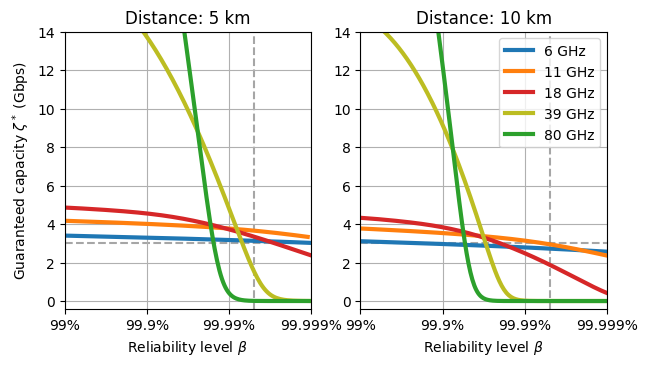

In [15]:
#fig, axes = plt.subplots(nrows=1, ncols=3, sharey=True, figsize=(15, 4))
#fig, axes = plt.subplots(nrows=1, ncols=3, sharey=True, figsize=(15, 3.6))
fig, axes = plt.subplots(nrows=1, ncols=2, sharey=True, figsize=(7, 3.6))

print("")
#print(f'Different bandwidths per carrier band: {(band_hz["diff"][6]/1e6):.0f} MHz @ 6 GHz, {(band_hz["diff"][23]/1e6):.0f} MHz @ 11, 18, 23 GHz and {(band_hz["diff"][80]/1e9):.0f} GHz @ 80 GHz')
for i, d_km in enumerate(df["d_km"].unique()):
  sli = df.loc[(df["d_km"] == d_km) & (df["same_bandwidth"] == "diff")& (df["rain_rate001"]=="Miami - 78.15 mm/h")  & (df["$N_p$"]==1)& (df["$N_h$"]==1)] #
  #_ = sns.lineplot(data=sli, x="nines", y="capacity_gbps", hue="$N_h$", lw=3, ax=axes[i], palette=sns.color_palette()[:2])
  #_ = sns.lineplot(data=sli, x="nines", y="capacity_gbps", hue="$N_h$", style="rain_rate001", lw=3, ax=axes[i], palette=sns.color_palette()[:3])
 # _ = sns.lineplot(data=sli, x="nines", y="capacity_gbps", hue='Carrier Frequency ($f_c$)', style="$N_h$", lw=3, ax=axes[i], palette=freq_colors)
  _ = sns.lineplot(data=sli, x="nines", y="capacity_gbps", hue='Carrier Freq. ($f_c$)', lw=3, ax=axes[i], palette=freq_colors)
  axes[i].grid(True)
  axes[i].set_ylabel(rf"Guaranteed capacity $\zeta^*$ (Gbps)")
  axes[i].set_title("Distance: {} km".format(d_km)) # covered in $N_h$ Hops
  axes[i].set_xlabel(rf"Reliability level $\beta$")
  axes[i].set_xticks(ticks=[2, 3, 4, 5], labels=['99%', '99.9%', '99.99%', '99.999%'])
  axes[i].set_xlim([2,5])
  # 99.995 lines
  axes[i].axvline( -np.log10(0.00005),  linestyle="--", color="black", alpha=0.35, zorder=1)
  # 3 Gbps line
  axes[i].axhline(3, linestyle="--", color="black", alpha=0.35, zorder=1)
  #axes[i].axhline(10,linestyle="--",color="black", alpha=0.35, zorder=1)
#_ = plt.tight_layout()
#plt.yscale("log")
for ax in axes:
    #plt.setp(ax.get_yticklabels(), visible=True)
    ax.tick_params(labelleft=True)  # show numeric tick labels again
    ax.set_ylim(-0.4, 14)

axes[0].get_legend().remove()
#axes[1].get_legend().remove()
axes[1].legend(loc="upper right")

#plt.savefig(f"cap-vs-reliability_fc-rainandmpfading-miami_w11.pdf", bbox_inches="tight", pad_inches=0.05) #
#plt.savefig(f"cap-vs-reliability_fc-rainandmpfading-nyc.pdf", bbox_inches="tight", pad_inches=0.05) #
#plt.savefig(f"cap-vs-reliability_fc-rainandmpfading-miami3.pdf", bbox_inches="tight", pad_inches=0.05)
#plt.savefig(f"cap-vs-reliability_fc-rainandmpfading-miami3-womp.pdf", bbox_inches="tight", pad_inches=0.05)
#plt.savefig(f"cap-vs-reliability_fc-rainandmpfadingandgas.pdf", bbox_inches="tight", pad_inches=0.05)
_ = plt.show()

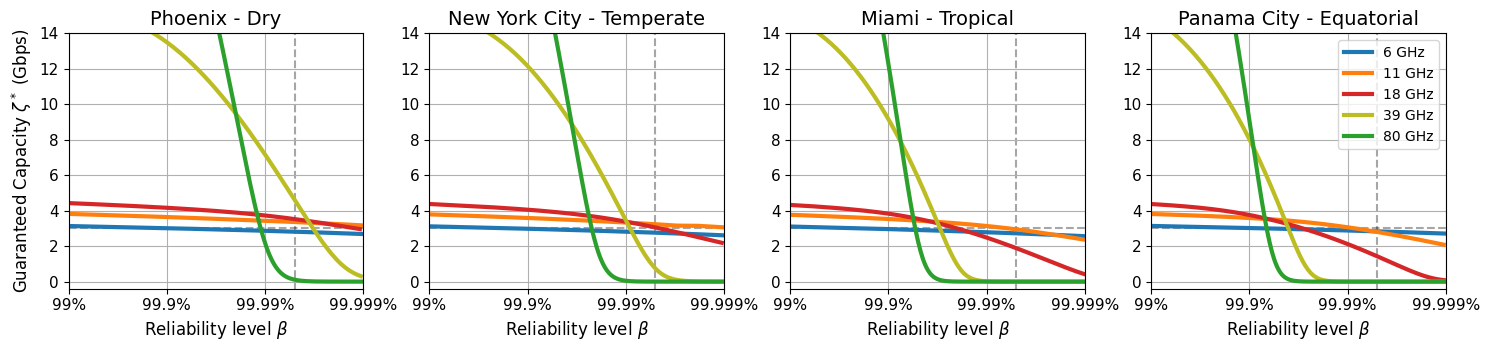

In [19]:
#fig, axes = plt.subplots(nrows=1, ncols=3, sharey=True, figsize=(15, 4))
fig, axes = plt.subplots(nrows=1, ncols=4, sharey=True, figsize=(15, 3.6))

print("")
#print(f'Different bandwidths per carrier band: {(band_hz["diff"][6]/1e6):.0f} MHz @ 6 GHz, {(band_hz["diff"][23]/1e6):.0f} MHz @ 11, 18, 23 GHz and {(band_hz["diff"][80]/1e9):.0f} GHz @ 80 GHz')
for i, rr in enumerate(df["rain_rate001"].unique()):
  sli = df.loc[(df["d_km"] == '10') & (df["same_bandwidth"] == "diff") & (df["rain_rate001"]==rr)  &(df["$N_p$"]==1)& (df["$N_h$"]==1)] #
  _ = sns.lineplot(data=sli, x="nines", y="capacity_gbps", hue='Carrier Freq. ($f_c$)', lw=3, ax=axes[i], palette=freq_colors)
  axes[i].grid(True)
  axes[i].set_ylabel(rf"Guaranteed Capacity $\zeta^*$ (Gbps)",fontsize=12)
  axes[i].set_title(f"{rr}") # covered in $N_h$ Hops
  axes[i].set_xlabel(rf"Reliability level $\beta$",fontsize=12)
  axes[i].set_xticks(ticks=[2, 3, 4, 5], labels=['99%', '99.9%', '99.99%', '99.999%'],fontsize=11)
  axes[i].tick_params(axis='y', labelsize=11)
  axes[i].set_xlim([2,5])
  # 99.995 lines
  axes[i].axvline( -np.log10(0.00005),  linestyle="--", color="black", alpha=0.35, zorder=1)
  # 3 Gbps line
  axes[i].axhline(3, linestyle="--", color="black", alpha=0.35, zorder=1)
_ = plt.tight_layout()
for ax in axes:
    ax.tick_params(labelleft=True)  # show numeric tick labels again
    ax.set_ylim(-0.4, 14)

axes[0].get_legend().remove()
axes[1].get_legend().remove()
axes[2].get_legend().remove()
axes[3].legend(title=None)



#manual titles
axes[0].set_title(f"Phoenix - Dry",fontsize=14)
axes[1].set_title(f"New York City - Temperate",fontsize=14)
axes[2].set_title(f"Miami - Tropical",fontsize=14)
axes[3].set_title(f"Panama City - Equatorial",fontsize=14)


#plt.savefig(f"_cap-vs-reliability_fc-rainandmpfading-cities5km_wo23_ls.pdf", bbox_inches="tight", pad_inches=0.05)
#plt.savefig(f"_cap-vs-reliability_fc-rainandmpfading-cities5km_wo23.pdf", bbox_inches="tight", pad_inches=0.05)

#plt.savefig(f"_cap-vs-reliability_fc-rainandmpfading-cities5km_old6_11gain.pdf", bbox_inches="tight", pad_inches=0.05)
#plt.savefig(f"_cap-vs-reliability_fc-rainandmpfading-cities5km_new6_11gain.pdf", bbox_inches="tight", pad_inches=0.05)
#plt.savefig(f"_cap-vs-reliability_fc-rainandmpfading-cities5km-womp.pdf", bbox_inches="tight", pad_inches=0.05)

#plt.savefig(f"cap-vs-reliability_fc-rainandmpfadingandgas.pdf", bbox_inches="tight", pad_inches=0.05)
#plt.savefig(f"_cap-vs-reliability_fc-rainandmpfading-cities5km.pdf", bbox_inches="tight", pad_inches=0.05)
#plt.savefig(f"_cap-vs-reliability_fc-rainandmpfading-cities10km.pdf", bbox_inches="tight", pad_inches=0.05)
#plt.savefig(f"_cap-vs-reliability_fc-rainandmpfading-cities15km.pdf", bbox_inches="tight", pad_inches=0.05)
_ = plt.show()

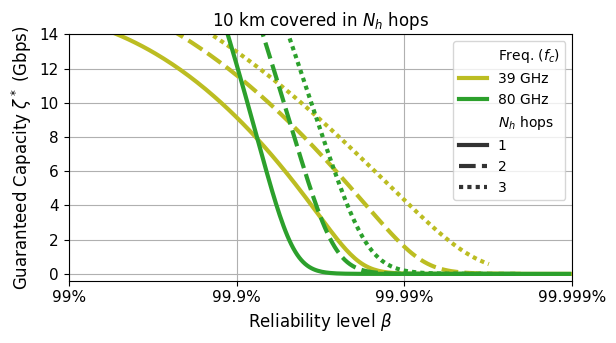

In [25]:
fig, axes = plt.subplots(nrows=1, ncols=1, sharey=True, figsize=(6.5, 3.2))

df['$N_h$ hops'] = df['$N_h$']
df['Freq. ($f_c$)'] = df['Carrier Freq. ($f_c$)']


print("")
#print(f'Different bandwidths per carrier band: {(band_hz["diff"][6]/1e6):.0f} MHz @ 6 GHz, {(band_hz["diff"][23]/1e6):.0f} MHz @ 11, 18, 23 GHz and {(band_hz["diff"][80]/1e9):.0f} GHz @ 80 GHz')
for i, d_km in enumerate(df["d_km"].unique()):
  sli = df.loc[(df["d_km"] == d_km) & (df["same_bandwidth"] == "diff")& (df["rain_rate001"]=='Miami - 78.15 mm/h')  & (df["$N_p$"]==1)& ( (df['Carrier Freq. ($f_c$)']=='39 GHz') | (df['Carrier Freq. ($f_c$)']=='80 GHz'))] #
  #_ = sns.lineplot(data=sli, x="nines", y="capacity_gbps", hue="$N_h$", lw=3, ax=axes[i], palette=sns.color_palette()[:2])
  #_ = sns.lineplot(data=sli, x="nines", y="capacity_gbps", hue="$N_h$", style="rain_rate001", lw=3, ax=axes[i], palette=sns.color_palette()[:3])
 # _ = sns.lineplot(data=sli, x="nines", y="capacity_gbps", hue='Carrier Frequency ($f_c$)', style="$N_h$", lw=3, ax=axes[i], palette=freq_colors)
  _ = sns.lineplot(data=sli, x="nines", y="capacity_gbps", hue='Freq. ($f_c$)', style='$N_h$ hops', lw=3, ax=axes, palette=freq_colors)
  axes.grid(True)
  axes.set_ylabel(rf"Guaranteed Capacity $\zeta^*$ (Gbps)",fontsize=12)
  axes.set_xlabel(rf"Reliability level $\beta$",fontsize=12)
  axes.set_xticks(ticks=[2, 3, 4, 5], labels=['99%', '99.9%', '99.99%', '99.999%'],fontsize=11)
  axes.tick_params(axis='y', labelsize=11)
  axes.set_title("{} km covered in $N_h$ hops".format(d_km)) # covered in $N_h$ Hops
  axes.set_xlim([2,5])
  # 99.995 lines
  #axes.axvline( -np.log10(0.00005),  linestyle="--", color="black", alpha=0.35, zorder=1)
  # 3 Gbps line
  #axes.axhline(3, linestyle="--", color="black", alpha=0.35, zorder=1)
  #axes[i].axhline(10,linestyle="--",color="black", alpha=0.35, zorder=1)
#_ = plt.tight_layout()
#plt.yscale("log")
axes.tick_params(labelleft=True)  # show numeric tick labels again
axes.set_ylim(-0.4, 14)

#axes[0].get_legend().remove()
#axes[1].get_legend().remove()
axes.legend(loc="upper right")
axes.legend().get_title().set_ha("center")

#plt.savefig(f"cap-vs-reliability_fc-rainandmpfading-miami-hopsHighBandOnly.pdf", bbox_inches="tight", pad_inches=0.05)

#plt.savefig(f"cap-vs-reliability_fc-rainandmpfading-panama-multihop3-no18.pdf", bbox_inches="tight", pad_inches=0.05) #
#plt.savefig(f"cap-vs-reliability_fc-rainandmpfading-nyc.pdf", bbox_inches="tight", pad_inches=0.05) #
#plt.savefig(f"cap-vs-reliability_fc-rainandmpfading-miami3.pdf", bbox_inches="tight", pad_inches=0.05)
#plt.savefig(f"cap-vs-reliability_fc-rainandmpfading-miami3-womp.pdf", bbox_inches="tight", pad_inches=0.05)
#plt.savefig(f"cap-vs-reliability_fc-rainandmpfadingandgas.pdf", bbox_inches="tight", pad_inches=0.05)
_ = plt.show()

#### combining

In [ ]:

def combine_bands_interp(
    df,
    combos,
    x_col,
    scenario_cols,      # explicitly given by user
    freq_col='Carrier Freq. ($f_c$)',
    cap_col='capacity_gbps',
    n_points=200,
):
    """
    Combine bands by interpolating each band onto a common x-grid and summing.
    Only groups by scenario_cols (explicit), and ignores/drops all others.
    """

    # --- Build a clean working frame containing ONLY needed columns ---
    keep_cols = scenario_cols + [x_col, freq_col, cap_col]
    df2 = df[keep_cols].copy()

    out_rows = []

    # --- Group only on the explicit scenario columns ---
    for key_vals, group in df2.groupby(scenario_cols):
        key_dict = dict(zip(scenario_cols, key_vals))

        for combo in combos:
            sub = group[group[freq_col].isin(combo)]
            if sub.empty:
                continue

            # Ensure all bands exist
            bands_present = set(sub[freq_col].unique())
            if not all(b in bands_present for b in combo):
                continue

            # Collect points per band
            band_data = {}
            x_mins, x_maxs = [], []
            ok = True

            for band in combo:
                g_band = sub[sub[freq_col] == band].sort_values(x_col)
                xs = g_band[x_col].to_numpy()
                ys = g_band[cap_col].to_numpy()

                if len(xs) < 2:
                    ok = False
                    break

                band_data[band] = (xs, ys)
                x_mins.append(xs.min())
                x_maxs.append(xs.max())

            if not ok:
                continue

            # Overlapping x-range
            x_min = max(x_mins)
            x_max = min(x_maxs)
            if not np.isfinite(x_min) or not np.isfinite(x_max) or x_max <= x_min:
                continue

            # Common grid
            x_common = np.linspace(x_min, x_max, n_points)

            # Sum capacities via interpolation
            cap_sum = np.zeros_like(x_common)
            for band in combo:
                xs, ys = band_data[band]
                cap_sum += np.interp(x_common, xs, ys)

            combo_label = " + ".join(combo)

            for xv, yv in zip(x_common, cap_sum):
                row = dict(key_dict)
                row[x_col] = xv
                row[freq_col] = combo_label
                row[cap_col] = yv
                out_rows.append(row)

    if not out_rows:
        return pd.DataFrame(columns=df.columns)

    # Reconstruct into the original column order:
    df_out = pd.DataFrame(out_rows)
    return df_out


scenario_cols = [
    "rain_rate001",
    "d_km",
    "same_bandwidth",
    "$N_h$",
    "$N_p$",
]


# Start with your filtered subset
df_diverse = df[(df["$N_h$"] == 1) & (df["$N_p$"] == 1)]

# Define the combinations of bands you want to synthetically sum
combos = [
    #("6 GHz", "39 GHz"),
    #("6 GHz", "80 GHz"),
    ("11 GHz", "39 GHz"),
    ("11 GHz", "80 GHz"),
]

# Suppose x-axis is 'nines'
df_combined = combine_bands_interp(
    df_diverse,
    combos=combos,
    x_col="nines",
    scenario_cols=scenario_cols,
    freq_col='Carrier Freq. ($f_c$)',
    cap_col='capacity_gbps',
    n_points=200,   # adjust if you want a denser or sparser grid
)

# If you want to plot “original 6 GHz” plus “combined bands”:
df_augmented = pd.concat(
    [
        #df_diverse[df_diverse['Carrier Freq. ($f_c$)'] == '6 GHz'],
        df_diverse[df_diverse['Carrier Freq. ($f_c$)'] == '11 GHz'],
        df_diverse[df_diverse['Carrier Freq. ($f_c$)'] == '39 GHz'],
        df_diverse[df_diverse['Carrier Freq. ($f_c$)'] == '80 GHz'],
        df_combined
    ],
    ignore_index=True
)


In [ ]:
df_augmented['Carrier Freq. ($f_c$)'].unique()


array(['11 GHz', '39 GHz', '80 GHz', '11 GHz + 39 GHz', '11 GHz + 80 GHz'],
      dtype=object)

In [ ]:
df['rain_rate001'].unique()

array(['Phoenix - 26.57 mm/h', 'New York City - 41.28 mm/h',
       'Miami - 78.15 mm/h', 'Panama City - 93.20 mm/h'], dtype=object)

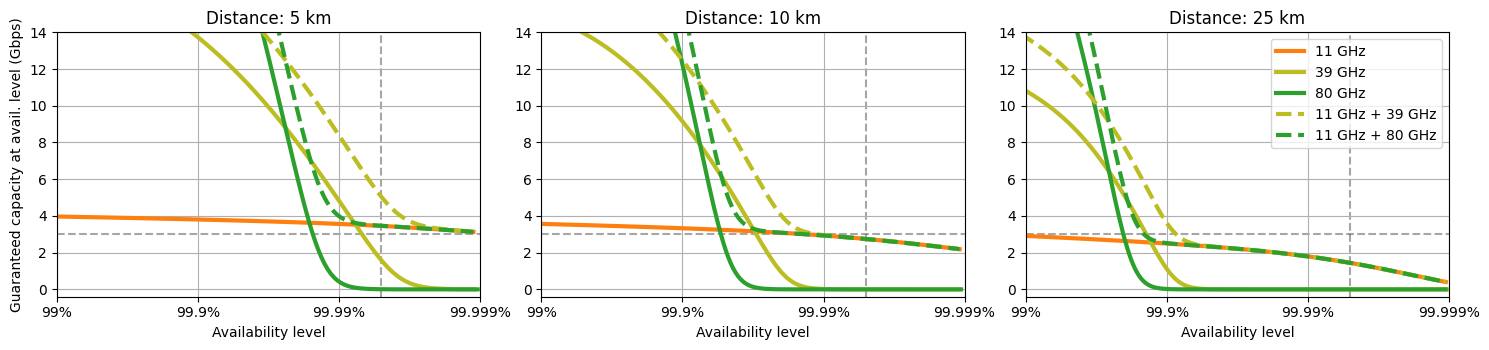

In [ ]:
#fig, axes = plt.subplots(nrows=1, ncols=3, sharey=True, figsize=(15, 4))
fig, axes = plt.subplots(nrows=1, ncols=3, sharey=True, figsize=(15, 3.6))

#df_plot = df_augmented# df_combined #
df_plot = df_augmented.copy()
#df_plot["band_type"] = np.where(
#    df_plot["Carrier Freq. ($f_c$)"].str.contains(r"\+"),
#    "combined",
#    "single"
#)

print("")
#print(f'Different bandwidths per carrier band: {(band_hz["diff"][6]/1e6):.0f} MHz @ 6 GHz, {(band_hz["diff"][23]/1e6):.0f} MHz @ 11, 18, 23 GHz and {(band_hz["diff"][80]/1e9):.0f} GHz @ 80 GHz')
for i, d_km in enumerate(df_plot["d_km"].unique()):
  sli = df_plot.loc[(df_plot["d_km"] == d_km) &  (df_plot["rain_rate001"]=='Miami - 78.15 mm/h')  & (df_plot["$N_p$"]==1)& (df_plot["$N_h$"]==1)] #
  #_ = sns.lineplot(data=sli, x="nines", y="capacity_gbps", hue="$N_h$", lw=3, ax=axes[i], palette=sns.color_palette()[:2])
  #_ = sns.lineplot(data=sli, x="nines", y="capacity_gbps", hue="$N_h$", style="rain_rate001", lw=3, ax=axes[i], palette=sns.color_palette()[:3])
 # _ = sns.lineplot(data=sli, x="nines", y="capacity_gbps", hue='Carrier Frequency ($f_c$)', style="$N_h$", lw=3, ax=axes[i], palette=freq_colors)
  #_ = sns.lineplot(data=sli, x="nines", y="capacity_gbps", hue='Carrier Freq. ($f_c$)', lw=3, ax=axes[i], palette=freq_colors)
  #_ = sns.lineplot(data=sli, x="nines", y="capacity_gbps", hue='Carrier Freq. ($f_c$)', lw=3, style="band_type", ax=axes[i], palette=freq_colors)
  single = sli[~sli['Carrier Freq. ($f_c$)'].str.contains(r"\+")]
  sns.lineplot(
        data=single,
        x="nines",
        y="capacity_gbps",
        hue='Carrier Freq. ($f_c$)',
        lw=3,
        ax=axes[i],
        palette=freq_colors,
        legend=(i == 2),  # only first subplot shows legend
    )
    # --- combined bands (dashed) ---
  combined = sli[sli['Carrier Freq. ($f_c$)'].str.contains(r"\+")]
  sns.lineplot(
        data=combined,
        x="nines",
        y="capacity_gbps",
        hue='Carrier Freq. ($f_c$)',
        lw=3,
        linestyle="--",
        ax=axes[i],
        palette=freq_colors,
        #legend=False,  # ← IMPORTANT: no extra legend entries
    )
  axes[i].grid(True)
  axes[i].set_ylabel("Guaranteed capacity at avail. level (Gbps)")
  axes[i].set_title("Distance: {} km".format(d_km)) # covered in $N_h$ Hops
  axes[i].set_xlabel("Reliability level")
  axes[i].set_xticks(ticks=[2, 3, 4, 5], labels=['99%', '99.9%', '99.99%', '99.999%'])
  axes[i].set_xlim([2,5])
  # 99.995 lines
  axes[i].axvline( -np.log10(0.00005),  linestyle="--", color="black", alpha=0.35, zorder=1)
  # 3 Gbps line
  axes[i].axhline(3, linestyle="--", color="black", alpha=0.35, zorder=1)
  _ = plt.tight_layout()
#plt.yscale("log")
ymin, ymax = axes[i].get_ylim()
for ax in axes:
    #plt.setp(ax.get_yticklabels(), visible=True)
    ax.tick_params(labelleft=True)  # show numeric tick labels again
    ax.set_ylim(-0.4, 14)

axes[0].get_legend().remove()
axes[1].get_legend().remove()
axes[2].legend(loc="upper right")

#plt.savefig(f"cap-vs-reliability_fc_combinedbands-miami_w11.pdf", bbox_inches="tight", pad_inches=0.05)
_ = plt.show()

In [ ]:
#df_augmented_stored=df_augmented.copy()

In [ ]:
df_augmented['Carrier Freq. ($f_c$)'] = (
    df_augmented['Carrier Freq. ($f_c$)']
    .str.replace(' GHz + ', ' & ', regex=False)
)

'''df_augmented_stored['Carrier Freq. ($f_c$)'] = (
    df_augmented_stored['Carrier Freq. ($f_c$)']
    .str.replace(' GHz + ', ' & ', regex=False)
)'''

"df_augmented_stored['Carrier Freq. ($f_c$)'] = (\n    df_augmented_stored['Carrier Freq. ($f_c$)']\n    .str.replace(' GHz + ', ' & ', regex=False)\n)"

In [ ]:
df_augmented['Carrier Freq. ($f_c$)'].unique()

array(['11 GHz', '39 GHz', '80 GHz', '11 & 39 GHz', '11 & 80 GHz'],
      dtype=object)

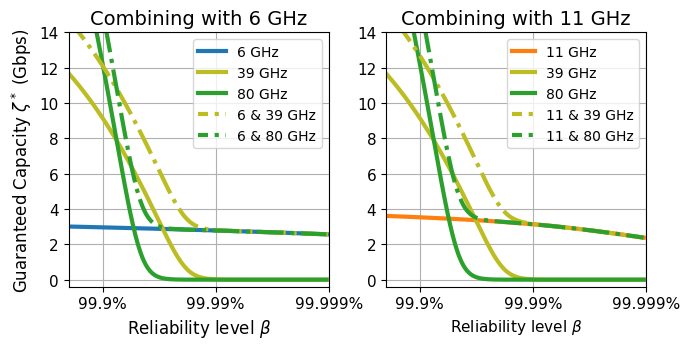

In [ ]:
#fig, axes = plt.subplots(nrows=1, ncols=3, sharey=True, figsize=(15, 4))
fig, axes = plt.subplots(nrows=1, ncols=2, sharey=True, figsize=(7, 3.6))

#df_plot = df_augmented# df_combined #
df_plot = df_augmented.copy()


print("")
#print(f'Different bandwidths per carrier band: {(band_hz["diff"][6]/1e6):.0f} MHz @ 6 GHz, {(band_hz["diff"][23]/1e6):.0f} MHz @ 11, 18, 23 GHz and {(band_hz["diff"][80]/1e9):.0f} GHz @ 80 GHz')
for i, d_km in enumerate(df_plot["d_km"].unique()):
  sli = df_plot.loc[(df_plot["d_km"] == d_km) &  (df_plot["rain_rate001"]=='Miami - 78.15 mm/h')  & (df_plot["$N_p$"]==1)& (df_plot["$N_h$"]==1)] #
  #_ = sns.lineplot(data=sli, x="nines", y="capacity_gbps", hue="$N_h$", lw=3, ax=axes[i], palette=sns.color_palette()[:2])
  #_ = sns.lineplot(data=sli, x="nines", y="capacity_gbps", hue="$N_h$", style="rain_rate001", lw=3, ax=axes[i], palette=sns.color_palette()[:3])
 # _ = sns.lineplot(data=sli, x="nines", y="capacity_gbps", hue='Carrier Frequency ($f_c$)', style="$N_h$", lw=3, ax=axes[i], palette=freq_colors)
  #_ = sns.lineplot(data=sli, x="nines", y="capacity_gbps", hue='Carrier Freq. ($f_c$)', lw=3, ax=axes[i], palette=freq_colors)
  #_ = sns.lineplot(data=sli, x="nines", y="capacity_gbps", hue='Carrier Freq. ($f_c$)', lw=3, style="band_type", ax=axes[i], palette=freq_colors)
  single = sli[~sli['Carrier Freq. ($f_c$)'].str.contains(r"\&")]
  sns.lineplot(
        data=single,
        x="nines",
        y="capacity_gbps",
        hue='Carrier Freq. ($f_c$)',
        lw=3,
        ax=axes[0],
        palette=freq_colors,
    )
    # --- combined bands (dashed) ---
  combined = sli[sli['Carrier Freq. ($f_c$)'].str.contains(r"\&")]
  sns.lineplot(
        data=combined,
        x="nines",
        y="capacity_gbps",
        hue='Carrier Freq. ($f_c$)',
        lw=3,
        linestyle=(4, (6.4, 1.6, 1.0, 1.6)), #"-.",
        ax=axes[0],
        palette=freq_colors,
        #legend=False,  # ← IMPORTANT: no extra legend entries
    )
  axes[0].grid(True)
  axes[0].set_ylabel(rf"Guaranteed Capacity $\zeta^*$ (Gbps)",fontsize=12)
  axes[0].set_title("Combining with 6 GHz",fontsize=14) # covered in $N_h$ Hops
  axes[0].set_xlabel(rf"Reliability level $\beta$",fontsize=12)
  axes[0].set_xticks(ticks=[2, 3, 4, 5], labels=['99%', '99.9%', '99.99%', '99.999%'],fontsize=11)
  axes[0].set_xlim([2.7,5])
  #axes[0].set_xlim([3,5])
  axes[0].tick_params(axis='y', labelsize=11)

  # 99.995 lines
  #axes[0].axvline( -np.log10(0.00005),  linestyle="--", color="black", alpha=0.35, zorder=1)
  # 3 Gbps line
  #axes[0].axhline(3, linestyle="--", color="black", alpha=0.35, zorder=1)
  _ = plt.tight_layout()
#plt.yscale("log")
ymin, ymax = axes[0].get_ylim()
axes[0].tick_params(labelleft=True)  # show numeric tick labels again
axes[0].set_ylim(-0.4, 14)
axes[0].legend(columnspacing=.94, handlelength=1.6)

#axes[0].get_legend().remove()
#axes[1].get_legend().remove()
axes[0].legend(loc="upper right")

df_plot=df_augmented_stored.copy()

for i, d_km in enumerate(df_plot["d_km"].unique()):
  sli = df_plot.loc[(df_plot["d_km"] == d_km) &  (df_plot["rain_rate001"]=='Miami - 78.15 mm/h')  & (df_plot["$N_p$"]==1)& (df_plot["$N_h$"]==1)] #
  #_ = sns.lineplot(data=sli, x="nines", y="capacity_gbps", hue="$N_h$", lw=3, ax=axes[i], palette=sns.color_palette()[:2])
  #_ = sns.lineplot(data=sli, x="nines", y="capacity_gbps", hue="$N_h$", style="rain_rate001", lw=3, ax=axes[i], palette=sns.color_palette()[:3])
 # _ = sns.lineplot(data=sli, x="nines", y="capacity_gbps", hue='Carrier Frequency ($f_c$)', style="$N_h$", lw=3, ax=axes[i], palette=freq_colors)
  #_ = sns.lineplot(data=sli, x="nines", y="capacity_gbps", hue='Carrier Freq. ($f_c$)', lw=3, ax=axes[i], palette=freq_colors)
  #_ = sns.lineplot(data=sli, x="nines", y="capacity_gbps", hue='Carrier Freq. ($f_c$)', lw=3, style="band_type", ax=axes[i], palette=freq_colors)
  single = sli[~sli['Carrier Freq. ($f_c$)'].str.contains(r"\&")]
  sns.lineplot(
        data=single,
        x="nines",
        y="capacity_gbps",
        hue='Carrier Freq. ($f_c$)',
        lw=3,
        ax=axes[1],
        palette=freq_colors,
    )
    # --- combined bands (dashed) ---
  combined = sli[sli['Carrier Freq. ($f_c$)'].str.contains(r"\&")]
  sns.lineplot(
        data=combined,
        x="nines",
        y="capacity_gbps",
        hue='Carrier Freq. ($f_c$)',
        lw=3,
        linestyle= (4, (6.4, 1.6, 1.0, 1.6)), #"-.",
        ax=axes[1],
        palette=freq_colors,
        #legend=False,  # ← IMPORTANT: no extra legend entries
    )
  axes[1].grid(True)
  axes[1].set_ylabel(rf"Guaranteed Capacity $\zeta^*$ (Gbps)",fontsize=11)
  axes[1].set_title("Combining with 11 GHz",fontsize=14) # covered in $N_h$ Hops
  axes[1].set_xlabel(rf"Reliability level $\beta$",fontsize=11)
  axes[1].set_xticks(ticks=[2, 3, 4, 5], labels=['99%', '99.9%', '99.99%', '99.999%'],fontsize=11)
  axes[1].set_xlim([2.7,5])
  #axes[1].set_xlim([3,5])
  axes[1].tick_params(axis='y', labelsize=11)
  # 99.995 lines
  #axes[1].axvline( -np.log10(0.00005),  linestyle="--", color="black", alpha=0.35, zorder=1)
  # 3 Gbps line
  #axes[1].axhline(3, linestyle="--", color="black", alpha=0.35, zorder=1)
  _ = plt.tight_layout()
#plt.yscale("log")
ymin, ymax = axes[0].get_ylim()
axes[1].tick_params(labelleft=True)  # show numeric tick labels again
axes[1].set_ylim(-0.4, 14)

#axes[0].get_legend().remove()
#axes[1].get_legend().remove()
axes[1].legend(loc="upper right")
axes[1].legend(columnspacing=.94, handlelength=1.6)

plt.subplots_adjust(wspace=0.22, hspace=0)


#axes[i].set_ylabel(rf"Guaranteed Capacity $\zeta^*$ (Gbps)",fontsize=12)
#axes[i].set_xlabel(rf"Availability level $\beta$",fontsize=12)
#  axes[i].set_xticks(ticks=[2, 3, 4, 5], labels=['99%', '99.9%', '99.99%', '99.999%'],fontsize=11)
#  axes[i].tick_params(axis='y', labelsize=11)

#plt.savefig(f"cap-vs-reliability_fc_combinedbands-miami5km_w11_newgains.pdf", bbox_inches="tight", pad_inches=0.05)
_ = plt.show()

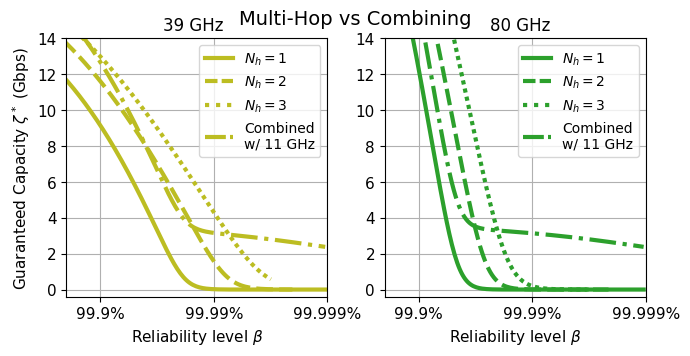

In [ ]:
#fig, axes = plt.subplots(nrows=1, ncols=3, sharey=True, figsize=(15, 4))
fig, axes = plt.subplots(nrows=1, ncols=2, sharey=True, figsize=(7, 3.6))
from matplotlib.lines import Line2D

df['$N_h$ hops'] = df['$N_h$']
df['Freq. ($f_c$)'] = df['Carrier Freq. ($f_c$)']


print("")
df_plot=df_augmented_stored.copy()

for i, d_km in enumerate(df["d_km"].unique()):
  sli = df.loc[(df["d_km"] == d_km) &  (df["rain_rate001"]=='Miami - 78.15 mm/h')  & (df["$N_p$"]==1) ] #(df_plot["$N_h$"]==1)
  #_ = sns.lineplot(data=sli, x="nines", y="capacity_gbps", hue="$N_h$", lw=3, ax=axes[i], palette=sns.color_palette()[:2])
  #_ = sns.lineplot(data=sli, x="nines", y="capacity_gbps", hue="$N_h$", style="rain_rate001", lw=3, ax=axes[i], palette=sns.color_palette()[:3])
 # _ = sns.lineplot(data=sli, x="nines", y="capacity_gbps", hue='Carrier Frequency ($f_c$)', style="$N_h$", lw=3, ax=axes[i], palette=freq_colors)
  #_ = sns.lineplot(data=sli, x="nines", y="capacity_gbps", hue='Carrier Freq. ($f_c$)', lw=3, ax=axes[i], palette=freq_colors)
  #_ = sns.lineplot(data=sli, x="nines", y="capacity_gbps", hue='Carrier Freq. ($f_c$)', lw=3, style="band_type", ax=axes[i], palette=freq_colors)
  single = sli[sli['Carrier Freq. ($f_c$)']=="39 GHz"]
  sns.lineplot(
        data=single,
        x="nines",
        y="capacity_gbps",
        hue='Carrier Freq. ($f_c$)',
        style='$N_h$ hops',
        lw=3,
        ax=axes[0],
        palette=freq_colors,
    )
    # --- combined bands (dashed) ---
  combined = df_plot[(df_plot['Carrier Freq. ($f_c$)'].str.contains(r"\&")) & (df_plot["$N_h$"]==1) & (df_plot['Carrier Freq. ($f_c$)']=="11 & 39 GHz") & (df_plot["rain_rate001"]=='Miami - 78.15 mm/h') ]
  sns.lineplot(
        data=combined,
        x="nines",
        y="capacity_gbps",
        hue='Carrier Freq. ($f_c$)',
        lw=3,
        linestyle="-.",
        ax=axes[0],
        palette=freq_colors,
        #marker='o', markevery=20,
        #legend=False,  # ← IMPORTANT: no extra legend entries
    )
  axes[0].grid(True)
  axes[0].set_ylabel(rf"Guaranteed Capacity $\zeta^*$ (Gbps)",fontsize=11)
  axes[0].set_title("39 GHz",fontsize=12,x=0.485) # covered in $N_h$ Hops
  axes[0].set_xlabel(rf"Reliability level $\beta$",fontsize=11)
  axes[0].set_xticks(ticks=[2, 3, 4, 5], labels=['99%', '99.9%', '99.99%', '99.999%'],fontsize=11)
  axes[0].set_xlim([2.7,5])
  axes[0].tick_params(axis='y', labelsize=11)
  # 99.995 lines
  #axes[1].axvline( -np.log10(0.00005),  linestyle="--", color="black", alpha=0.35, zorder=1)
  # 3 Gbps line
  #axes[1].axhline(3, linestyle="--", color="black", alpha=0.35, zorder=1)
  _ = plt.tight_layout()
#plt.yscale("log")
ymin, ymax = axes[0].get_ylim()
axes[0].tick_params(labelleft=True)  # show numeric tick labels again
axes[0].set_ylim(-0.4, 14)

#axes[0].get_legend().remove()
#axes[1].get_legend().remove()
axes[0].legend(loc="upper right")
axes[0].legend(columnspacing=.94, handlelength=1.6)
axes[0].legend().remove()

legend_elements = [
    Line2D([0], [0], color=freq_colors["39 GHz"],   lw=3, linestyle="-", label="$N_h=1$"),
    Line2D([0], [0], color=freq_colors["39 GHz"],  lw=3, linestyle=(0,(3,1)), label="$N_h=2$"),
    Line2D([0], [0], color=freq_colors["39 GHz"], lw=3, linestyle=":", label="$N_h=3$"),
    Line2D([0], [0], color=freq_colors["39 GHz"],lw=3, linestyle=(0,(5,1)), label="Combined\nw/ 11 GHz"),
]

axes[0].legend(handles=legend_elements, loc="upper right", frameon=True)

df_plot=df_augmented_stored.copy()

for i, d_km in enumerate(df["d_km"].unique()):
  sli = df.loc[(df["d_km"] == d_km) &  (df["rain_rate001"]=='Miami - 78.15 mm/h')  & (df["$N_p$"]==1) ] #(df_plot["$N_h$"]==1)
  #_ = sns.lineplot(data=sli, x="nines", y="capacity_gbps", hue="$N_h$", lw=3, ax=axes[i], palette=sns.color_palette()[:2])
  #_ = sns.lineplot(data=sli, x="nines", y="capacity_gbps", hue="$N_h$", style="rain_rate001", lw=3, ax=axes[i], palette=sns.color_palette()[:3])
 # _ = sns.lineplot(data=sli, x="nines", y="capacity_gbps", hue='Carrier Frequency ($f_c$)', style="$N_h$", lw=3, ax=axes[i], palette=freq_colors)
  #_ = sns.lineplot(data=sli, x="nines", y="capacity_gbps", hue='Carrier Freq. ($f_c$)', lw=3, ax=axes[i], palette=freq_colors)
  #_ = sns.lineplot(data=sli, x="nines", y="capacity_gbps", hue='Carrier Freq. ($f_c$)', lw=3, style="band_type", ax=axes[i], palette=freq_colors)
  single = sli[sli['Carrier Freq. ($f_c$)']=="80 GHz"]
  sns.lineplot(
        data=single,
        x="nines",
        y="capacity_gbps",
        hue='Carrier Freq. ($f_c$)',
        style='$N_h$ hops',
        lw=3,
        ax=axes[1],
        palette=freq_colors,
    )
    # --- combined bands (dashed) ---
  combined = df_plot[(df_plot['Carrier Freq. ($f_c$)'].str.contains(r"\&")) & (df_plot["$N_h$"]==1) & (df_plot['Carrier Freq. ($f_c$)']=="11 & 80 GHz") & (df_plot["rain_rate001"]=='Miami - 78.15 mm/h') ]
  sns.lineplot(
        data=combined,
        x="nines",
        y="capacity_gbps",
        hue='Carrier Freq. ($f_c$)',
        lw=3,
        linestyle="-.",
        ax=axes[1],
        palette=freq_colors,
        #marker='o', markevery=20,
        #legend=False,  # ← IMPORTANT: no extra legend entries
    )
  axes[1].grid(True)
  axes[1].set_ylabel(rf"Guaranteed Capacity $\zeta^*$ (Gbps)",fontsize=11)
  axes[1].set_title("80 GHz",fontsize=12,x=0.52) # covered in $N_h$ Hops
  axes[1].set_xlabel(rf"Reliability level $\beta$",fontsize=11)
  axes[1].set_xticks(ticks=[2, 3, 4, 5], labels=['99%', '99.9%', '99.99%', '99.999%'],fontsize=11)
  axes[1].set_xlim([2.7,5])
  axes[1].tick_params(axis='y', labelsize=11)
  # 99.995 lines
  #axes[1].axvline( -np.log10(0.00005),  linestyle="--", color="black", alpha=0.35, zorder=1)
  # 3 Gbps line
  #axes[1].axhline(3, linestyle="--", color="black", alpha=0.35, zorder=1)
  _ = plt.tight_layout()
#plt.yscale("log")
ymin, ymax = axes[0].get_ylim()
axes[1].tick_params(labelleft=True)  # show numeric tick labels again
axes[1].set_ylim(-0.4, 14)

#axes[0].get_legend().remove()
#axes[1].get_legend().remove()
#axes[1].legend(loc="upper right")
axes[1].legend(columnspacing=.94, handlelength=1.6)
axes[1].legend().remove()

legend_elements = [
    Line2D([0], [0], color=freq_colors["80 GHz"],   lw=3, linestyle="-", label="$N_h=1$"),
    Line2D([0], [0], color=freq_colors["80 GHz"],  lw=3, linestyle=(0,(3,1)), label="$N_h=2$"),
    Line2D([0], [0], color=freq_colors["80 GHz"], lw=3, linestyle=":", label="$N_h=3$"),
    Line2D([0], [0], color=freq_colors["80 GHz"],lw=3, linestyle=(0,(5,1)), label="Combined\nw/ 11 GHz"),
]

axes[1].legend(handles=legend_elements, loc="upper right", frameon=True)

plt.subplots_adjust(wspace=0.22, hspace=0)
fig.suptitle("Multi-Hop vs Combining", fontsize=14,y=0.977, x=0.515)


#axes[i].set_ylabel(rf"Guaranteed Capacity $\zeta^*$ (Gbps)",fontsize=12)
#axes[i].set_xlabel(rf"Reliability level $\beta$",fontsize=12)
#  axes[i].set_xticks(ticks=[2, 3, 4, 5], labels=['99%', '99.9%', '99.99%', '99.999%'],fontsize=11)
#  axes[i].tick_params(axis='y', labelsize=11)

#plt.savefig(f"cap-vs-reliability_fc_combinedvsmultihop-miami10km_both_newgains.pdf", bbox_inches="tight", pad_inches=0.05)
#plt.savefig(f"cap-vs-reliability_fc_combinedvsmultihop-miami10km_both.pdf", bbox_inches="tight", pad_inches=0.05)
#plt.savefig(f"cap-vs-reliability_fc_combinedbands-miami10km_w11.pdf", bbox_inches="tight", pad_inches=0.05)
_ = plt.show()

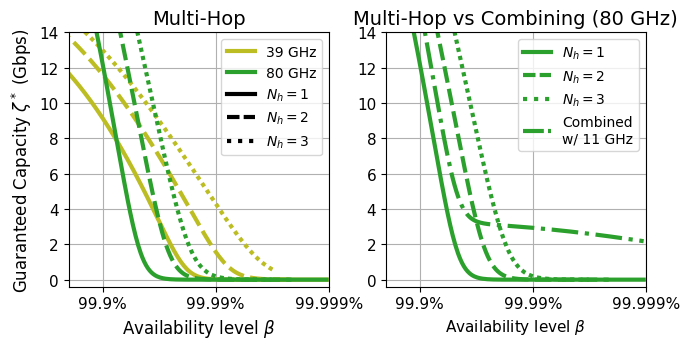

In [ ]:
#fig, axes = plt.subplots(nrows=1, ncols=3, sharey=True, figsize=(15, 4))
fig, axes = plt.subplots(nrows=1, ncols=2, sharey=True, figsize=(7, 3.6))
from matplotlib.lines import Line2D


df['$N_h$ hops'] = df['$N_h$']
df['Freq. ($f_c$)'] = df['Carrier Freq. ($f_c$)']


print("")
#print(f'Different bandwidths per carrier band: {(band_hz["diff"][6]/1e6):.0f} MHz @ 6 GHz, {(band_hz["diff"][23]/1e6):.0f} MHz @ 11, 18, 23 GHz and {(band_hz["diff"][80]/1e9):.0f} GHz @ 80 GHz')
for i, d_km in enumerate(df["d_km"].unique()):
  sli = df.loc[(df["d_km"] == d_km) & (df["same_bandwidth"] == "diff")& (df["rain_rate001"]=='Miami - 78.15 mm/h')  & (df["$N_p$"]==1)& ( (df['Carrier Freq. ($f_c$)']=='39 GHz') | (df['Carrier Freq. ($f_c$)']=='80 GHz'))] #
  #_ = sns.lineplot(data=sli, x="nines", y="capacity_gbps", hue="$N_h$", lw=3, ax=axes[i], palette=sns.color_palette()[:2])
  #_ = sns.lineplot(data=sli, x="nines", y="capacity_gbps", hue="$N_h$", style="rain_rate001", lw=3, ax=axes[i], palette=sns.color_palette()[:3])
 # _ = sns.lineplot(data=sli, x="nines", y="capacity_gbps", hue='Carrier Frequency ($f_c$)', style="$N_h$", lw=3, ax=axes[i], palette=freq_colors)
  _ = sns.lineplot(data=sli, x="nines", y="capacity_gbps", hue='Freq. ($f_c$)', style='$N_h$ hops', lw=3, ax=axes[0], palette=freq_colors)
  axes[0].grid(True)
  axes[0].set_ylabel(rf"Guaranteed Capacity $\zeta^*$ (Gbps)",fontsize=12)
  axes[0].set_title("Multi-Hop",fontsize=14) # covered in $N_h$ Hops
  axes[0].set_xlabel(rf"Reliability level $\beta$",fontsize=12)
  axes[0].set_xticks(ticks=[2, 3, 4, 5], labels=['99%', '99.9%', '99.99%', '99.999%'],fontsize=11)
  axes[0].set_xlim([2.7,5])
  axes[0].tick_params(axis='y', labelsize=11)

  # 99.995 lines
  #axes[0].axvline( -np.log10(0.00005),  linestyle="--", color="black", alpha=0.35, zorder=1)
  # 3 Gbps line
  #axes[0].axhline(3, linestyle="--", color="black", alpha=0.35, zorder=1)
  _ = plt.tight_layout()
#plt.yscale("log")
ymin, ymax = axes[0].get_ylim()
axes[0].tick_params(labelleft=True)  # show numeric tick labels again
axes[0].set_ylim(-0.4, 14)
#axes[0].legend(columnspacing=.94, handlelength=1.6)

#axes[0].get_legend().remove()
#axes[1].get_legend().remove()
#axes[0].legend(loc="upper right")
#axes[0].legend(columnspacing=.94, handlelength=1.6)
axes[0].legend().remove()
legend_elements1 = [
    Line2D([0], [0], color=freq_colors["39 GHz"],   lw=3, linestyle="-", label="39 GHz"),
    Line2D([0], [0], color=freq_colors["80 GHz"],  lw=3, linestyle="-", label="80 GHz"),
    Line2D([0], [0], color="black", lw=3, linestyle="-", label="$N_h=1$"),
    Line2D([0], [0], color="black", lw=3, linestyle=(0,(3,1)), label="$N_h=2$"),
    Line2D([0], [0], color="black", lw=3, linestyle=":", label="$N_h=3$"),
]

axes[0].legend(handles=legend_elements1, loc="upper right", frameon=True)

df_plot=df_augmented.copy()

for i, d_km in enumerate(df["d_km"].unique()):
  sli = df.loc[(df["d_km"] == d_km) &  (df["rain_rate001"]=='Miami - 78.15 mm/h')  & (df["$N_p$"]==1) ] #(df_plot["$N_h$"]==1)
  #_ = sns.lineplot(data=sli, x="nines", y="capacity_gbps", hue="$N_h$", lw=3, ax=axes[i], palette=sns.color_palette()[:2])
  #_ = sns.lineplot(data=sli, x="nines", y="capacity_gbps", hue="$N_h$", style="rain_rate001", lw=3, ax=axes[i], palette=sns.color_palette()[:3])
 # _ = sns.lineplot(data=sli, x="nines", y="capacity_gbps", hue='Carrier Frequency ($f_c$)', style="$N_h$", lw=3, ax=axes[i], palette=freq_colors)
  #_ = sns.lineplot(data=sli, x="nines", y="capacity_gbps", hue='Carrier Freq. ($f_c$)', lw=3, ax=axes[i], palette=freq_colors)
  #_ = sns.lineplot(data=sli, x="nines", y="capacity_gbps", hue='Carrier Freq. ($f_c$)', lw=3, style="band_type", ax=axes[i], palette=freq_colors)
  single = sli[sli['Carrier Freq. ($f_c$)']=="80 GHz"]
  sns.lineplot(
        data=single,
        x="nines",
        y="capacity_gbps",
        hue='Carrier Freq. ($f_c$)',
        style='$N_h$ hops',
        lw=3,
        ax=axes[1],
        palette=freq_colors,
    )
    # --- combined bands (dashed) ---
  combined = df_plot[(df_plot['Carrier Freq. ($f_c$)'].str.contains(r"\&")) & (df_plot["$N_h$"]==1) & (df_plot['Carrier Freq. ($f_c$)']=="11 & 80 GHz") & (df_plot["rain_rate001"]=='Miami - 78.15 mm/h') ]
  sns.lineplot(
        data=combined,
        x="nines",
        y="capacity_gbps",
        hue='Carrier Freq. ($f_c$)',
        lw=3,
        linestyle="-.",
        ax=axes[1],
        palette=freq_colors,
        #marker='o', markevery=20,
        #legend=False,  # ← IMPORTANT: no extra legend entries
    )
  axes[1].grid(True)
  axes[1].set_ylabel(rf"Guaranteed Capacity $\zeta^*$ (Gbps)",fontsize=11)
  axes[1].set_title("Multi-Hop vs Combining (80 GHz)",fontsize=14) # covered in $N_h$ Hops
  axes[1].set_xlabel(rf"Reliability level $\beta$",fontsize=11)
  axes[1].set_xticks(ticks=[2, 3, 4, 5], labels=['99%', '99.9%', '99.99%', '99.999%'],fontsize=11)
  axes[1].set_xlim([2.7,5])
  axes[1].tick_params(axis='y', labelsize=11)
  # 99.995 lines
  #axes[1].axvline( -np.log10(0.00005),  linestyle="--", color="black", alpha=0.35, zorder=1)
  # 3 Gbps line
  #axes[1].axhline(3, linestyle="--", color="black", alpha=0.35, zorder=1)
  _ = plt.tight_layout()
#plt.yscale("log")
ymin, ymax = axes[0].get_ylim()
axes[1].tick_params(labelleft=True)  # show numeric tick labels again
axes[1].set_ylim(-0.4, 14)

#axes[0].get_legend().remove()
#axes[1].get_legend().remove()
axes[1].legend().remove()

legend_elements = [
    Line2D([0], [0], color=freq_colors["80 GHz"],   lw=3, linestyle="-", label="$N_h=1$"),
    Line2D([0], [0], color=freq_colors["80 GHz"],  lw=3, linestyle=(0,(3,1)), label="$N_h=2$"),
    Line2D([0], [0], color=freq_colors["80 GHz"], lw=3, linestyle=":", label="$N_h=3$"),
    Line2D([0], [0], color=freq_colors["80 GHz"],lw=3, linestyle=(0,(5,1)), label="Combined\nw/ 11 GHz"),
]

axes[1].legend(handles=legend_elements, loc="upper right", frameon=True)
#axes[1].legend(loc="upper right")
#axes[1].legend(columnspacing=.94, handlelength=1.6)


plt.subplots_adjust(wspace=0.22, hspace=0)


#axes[i].set_ylabel(rf"Guaranteed Capacity $\zeta^*$ (Gbps)",fontsize=12)
#axes[i].set_xlabel(rf"Reliability level $\beta$",fontsize=12)
#  axes[i].set_xticks(ticks=[2, 3, 4, 5], labels=['99%', '99.9%', '99.99%', '99.999%'],fontsize=11)
#  axes[i].tick_params(axis='y', labelsize=11)

#plt.savefig(f"cap-vs-reliability_fc_combinedvsmultihop-miami10km_80g.pdf", bbox_inches="tight", pad_inches=0.05)
_ = plt.show()

In [ ]:
combined

,p,rain_rate001,d_km,Carrier Freq. ($f_c$),capacity_gbps,same_bandwidth,$N_h$,$N_p$,gas_att,nines,$N_h$ hops,Freq. ($f_c$)
2686,NaN,Miami - 78.15 mm/h,10,11 & 39 GHz,18.914427,diff,1,1,NaN,1.853570,NaN,NaN
2687,NaN,Miami - 78.15 mm/h,10,11 & 39 GHz,18.875920,diff,1,1,NaN,1.869287,NaN,NaN
2688,NaN,Miami - 78.15 mm/h,10,11 & 39 GHz,18.837075,diff,1,1,NaN,1.885003,NaN,NaN
2689,NaN,Miami - 78.15 mm/h,10,11 & 39 GHz,18.797600,diff,1,1,NaN,1.900719,NaN,NaN
2690,NaN,Miami - 78.15 mm/h,10,11 & 39 GHz,18.757349,diff,1,1,NaN,1.916435,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
4081,NaN,Phoenix - 26.57 mm/h,10,11 & 39 GHz,3.481322,diff,1,1,NaN,4.903869,NaN,NaN
4082,NaN,Phoenix - 26.57 mm/h,10,11 & 39 GHz,3.425822,diff,1,1,NaN,4.921719,NaN,NaN
4083,NaN,Phoenix - 26.57 mm/h,10,11 & 39 GHz,3.376548,diff,1,1,NaN,4.939569,NaN,NaN
4084,NaN,Phoenix - 26.57 mm/h,10,11 & 39 GHz,3.330754,diff,1,1,NaN,4.957419,NaN,NaN
